In [3]:
import pandas as pd
from pathlib import Path

In [4]:
DATA_PATH = Path("../backend/data/archive-5")

In [5]:
solar_df = pd.read_csv(DATA_PATH / "solar.csv")
lunar_df = pd.read_csv(DATA_PATH / "lunar.csv")

In [9]:
solar_df.shape, lunar_df.shape

((11898, 15), (12064, 16))

In [14]:
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11898 entries, 0 to 11897
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Catalog Number     11898 non-null  int64  
 1   Calendar Date      11898 non-null  object 
 2   Eclipse Time       11898 non-null  object 
 3   Delta T (s)        11898 non-null  int64  
 4   Lunation Number    11898 non-null  int64  
 5   Saros Number       11898 non-null  int64  
 6   Eclipse Type       11898 non-null  object 
 7   Gamma              11898 non-null  float64
 8   Eclipse Magnitude  11898 non-null  float64
 9   Latitude           11898 non-null  object 
 10  Longitude          11898 non-null  object 
 11  Sun Altitude       11898 non-null  int64  
 12  Sun Azimuth        11898 non-null  int64  
 13  Path Width (km)    7698 non-null   object 
 14  Central Duration   7698 non-null   object 
dtypes: float64(2), int64(6), object(7)
memory usage: 1.4+ MB


In [13]:
lunar_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12064 entries, 0 to 12063
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Catalog Number                  12064 non-null  int64  
 1   Calendar Date                   12064 non-null  object 
 2   Eclipse Time                    12064 non-null  object 
 3   Delta T (s)                     12064 non-null  int64  
 4   Lunation Number                 12064 non-null  int64  
 5   Saros Number                    12064 non-null  int64  
 6   Eclipse Type                    12064 non-null  object 
 7   Quincena Solar Eclipse          12064 non-null  object 
 8   Gamma                           12064 non-null  float64
 9   Penumbral Magnitude             12064 non-null  float64
 10  Umbral Magnitude                12064 non-null  float64
 11  Latitude                        12064 non-null  object 
 12  Longitude                       

In [17]:
solar_df.isnull().sum()

Catalog Number          0
Calendar Date           0
Eclipse Time            0
Delta T (s)             0
Lunation Number         0
Saros Number            0
Eclipse Type            0
Gamma                   0
Eclipse Magnitude       0
Latitude                0
Longitude               0
Sun Altitude            0
Sun Azimuth             0
Path Width (km)      4200
Central Duration     4200
dtype: int64

Soldatasetet innehåller 4 200 saknade värden för Path Width (km) och Central Duration. Dessa värden togs inte bort eftersom de kan vara relaterade till typen av solförmörkelse.

In [19]:
lunar_df.isnull().sum()

Catalog Number                    0
Calendar Date                     0
Eclipse Time                      0
Delta T (s)                       0
Lunation Number                   0
Saros Number                      0
Eclipse Type                      0
Quincena Solar Eclipse            0
Gamma                             0
Penumbral Magnitude               0
Umbral Magnitude                  0
Latitude                          0
Longitude                         0
Penumbral Eclipse Duration (m)    0
Partial Eclipse Duration (m)      0
Total Eclipse Duration (m)        0
dtype: int64

In [20]:
solar_df.duplicated().sum(), lunar_df.duplicated().sum()

(np.int64(0), np.int64(0))

In [22]:
solar_df.describe()

,Catalog Number,Delta T (s),Lunation Number,Saros Number,Gamma,Eclipse Magnitude,Sun Altitude,Sun Azimuth
count,11898.000000,11898.000000,11898.000000,11898.000000,11898.000000,11898.000000,11898.000000,11898.000000
mean,5949.500000,12142.172802,-18546.959321,87.483190,-0.002469,0.812748,36.505295,180.264330
std,3434.801086,13583.402888,17906.572982,48.380284,0.900860,0.300398,32.417350,110.745408
min,1.000000,-6.000000,-49456.000000,-13.000000,-1.569000,0.000000,0.000000,0.000000
25%,2975.250000,970.250000,-33954.750000,47.000000,-0.786575,0.675925,0.000000,89.000000
50%,5949.500000,5636.500000,-18495.000000,87.000000,-0.003850,0.950600,38.000000,180.000000
75%,8923.750000,20943.500000,-3039.250000,128.000000,0.776900,1.018400,66.000000,272.000000
max,11898.000000,46438.000000,12378.000000,190.000000,1.570600,1.081300,90.000000,360.000000


In [23]:
solar_df.describe()
lunar_df.describe()

,Catalog Number,Delta T (s),Lunation Number,Saros Number,Gamma,Penumbral Magnitude,Umbral Magnitude,Penumbral Eclipse Duration (m)
count,12064.000000,12064.000000,12064.000000,12064.000000,12064.000000,12064.000000,12064.000000,12064.000000
mean,6032.500000,12116.476044,-18531.392822,80.505056,0.002490,1.418656,0.400175,269.971941
std,3482.721158,13584.785584,17887.218741,48.416007,0.910505,0.832263,0.832954,79.945444
min,1.000000,-6.000000,-49456.000000,-20.000000,-1.582700,0.000400,-1.095800,5.200000
25%,3016.750000,962.000000,-33923.250000,40.000000,-0.788825,0.684425,-0.334000,223.100000
50%,6032.500000,5597.000000,-18445.500000,80.000000,0.001750,1.417450,0.400450,295.000000
75%,9048.250000,20901.500000,-3067.750000,121.000000,0.791725,2.136900,1.117925,327.800000
max,12064.000000,46437.000000,12378.000000,183.000000,1.579100,2.908900,1.882100,379.500000


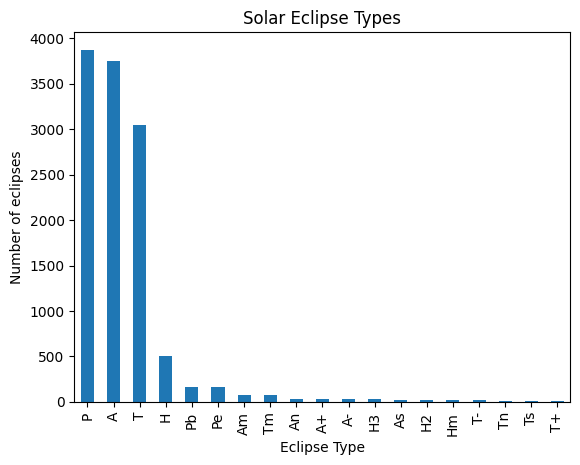

In [25]:
import matplotlib.pyplot as plt

solar_df["Eclipse Type"].value_counts().plot(kind="bar")
plt.title("Solar Eclipse Types")
plt.xlabel("Eclipse Type")
plt.ylabel("Number of eclipses")
plt.show()

Delvisa solförmörkelsen (P) är den vanligaste typen i datasetet, med 3 875 registrerade solförmörkelser